<a href="https://colab.research.google.com/github/oromiaGodanna/Data_as_text_/blob/main/text_as_data_workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Text as Data

People share a lot about themselves and their experiences through text on digital platforms. This text can tell us something about how people communicate, interpret experiences, and make sense of their social and cultural worlds. It also allows us to examine patterns across individuals, groups, and contexts, including how ideas and narratives vary or change.

These patterns might involve how people express identities, emotions, beliefs, or norms. Computational methods help us examine them across large amounts of text while still allowing us to return to the original data and interpret it in context.

In this workshop, we will explore how we can do unsupervised text analysis, we will move through three broad stages: preparing and representing text (turning raw text into something we can compare), exploration (looking for patterns in words and language use), and discovery (finding structure or groups without predefined labels).

# Table of Contents

- [Getting Started](#scrollTo=tad-002)
  - [Import Libraries](#scrollTo=tad-004)
- [Selection and Representation](#scrollTo=tad-008)
  - [Text Preprocessing](#scrollTo=tad-010)
    - [Clean Only What We Need](#scrollTo=tad-010)
    - [Validate the Cleaning Choices](#scrollTo=validate-cleaning)
    - [Filter English Text](#scrollTo=tad-012)
    - [A Note on Bot Detection](#scrollTo=bot-detection-note)
    - [A Balanced Sample](#scrollTo=tad-014)
  - [Representing Text Numerically](#scrollTo=tad-016)
    - [Before representing the text](#scrollTo=tad-016)
    - [Word Counts](#scrollTo=tad-017)
    - [TF–IDF](#scrollTo=tad-019)
    - [Sentence Embeddings](#scrollTo=tad-021)
    - [What are embeddings?](#scrollTo=tad-021)
- [Exploring Text](#scrollTo=tad-023)
  - [Posting Patterns](#scrollTo=tad-023)
  - [Words and N-grams](#scrollTo=tad-025)
  - [Distinctive Terms](#scrollTo=tad-027)
- [Exploration to Measurement](#scrollTo=tad-031)
- [Discovery from Unlabeled Text](#scrollTo=tad-033)
  - [Semantic Similarity](#scrollTo=tad-033)
    - [Cosine Similarity and Nearest Neighbors](#scrollTo=tad-034)
- [Finding Structure - Topic Modeling](#scrollTo=tad-038)
  - [Dimensionality Reduction](#scrollTo=tad-038)
    - [PCA](#scrollTo=tad-039)
    - [UMAP](#scrollTo=tad-041)
  - [Clustering](#scrollTo=tad-043)
    - [K-means](#scrollTo=tad-044)
    - [HDBSCAN](#scrollTo=tad-046)
- [From Clusters to Topics](#scrollTo=tad-048)
  - [Characteristic Words: c-TF–IDF](#scrollTo=tad-049)
  - [Representative Documents](#scrollTo=tad-051)
- [BERTopic: Putting the Pieces Together](#scrollTo=tad-053)
- [Evaluation](#scrollTo=tad-058)
- [References and Further Reading](#scrollTo=33GoO1OxsYgb)

## Getting Started

A CPU runtime is sufficient, but a GPU runtime can speed up embeddings. Please run the following cell to download all the needed packages.


In [ ]:
%pip install -q numpy pandas scipy scikit-learn matplotlib langdetect sentence-transformers umap-learn hdbscan bertopic demoji vaderSentiment


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


### Import Libraries


In [ ]:
from pathlib import Path
import hashlib
import json
import re
import textwrap
import importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import sparse
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.cluster import KMeans


### Load File and Choose Settings

We use up to **80 English posts per user**. You can change these default parameters later to explore how selection affects the results.


In [ ]:
SEED = 42
# Download the workshop CSV from GitHub when the local file is unavailable.
DATA_URL = "https://raw.githubusercontent.com/oromiaGodanna/Data_as_text_/main/pseudonymized_posts_uncleaned.csv"
DATA_PATH = Path("../bluesky_data/20260923T132359274680Z/pseudonymized_posts_uncleaned.csv")
if not DATA_PATH.exists():
    if DATA_URL:
        from urllib.request import urlopen
        DATA_PATH = Path("workshop_data/pseudonymized_posts_uncleaned.csv")
        with urlopen(DATA_URL, timeout=60) as response:
            csv_bytes = response.read()
        DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
        DATA_PATH.write_bytes(csv_bytes)
    else:
        raise FileNotFoundError(
            "Set DATA_URL to the public GitHub raw CSV URL, or update DATA_PATH to a local CSV."
        )
print(f"Using dataset: {DATA_PATH}")
ASSETS = Path("workshop_assets")
ASSETS.mkdir(exist_ok=True)
RESULTS = Path("workshop_results")
RESULTS.mkdir(exist_ok=True)
REPRESENTATION = "embeddings"  # or "tfidf" for the vocabulary-based route
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
POSTS_PER_USER = 80
MIN_WORDS = 5
LANGUAGE_SCORE_THRESHOLD = 0.80
DROP_MAJORITY_NON_ENGLISH_USERS = True  # False: keep English posts from any user.
MIN_ELIGIBLE_POSTS = 20  # Avoid letting one tiny history determine the balanced sample.
K = 6

plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
pd.set_option("display.max_colwidth", 130)
pd.set_option("display.max_rows", 20)

def show_posts(frame, n=5):
    """Show original text alongside the cleaned analysis text when available."""
    for _, row in frame.head(n).iterrows():
        print(f"{row['uid']}  | {row['time']}")
        print("Original text:")
        print(textwrap.fill(str(row['post']), width=100))
        if "text" in frame.columns:
            print("Cleaned text (used for analysis):")
            print(textwrap.fill(str(row['text']), width=100))
        print()


Using dataset: workshop_data/pseudonymized_posts_uncleaned.csv


## Selection and Representation


**Inspecting Real-World Text (What does social-media text actually look like?)**

Posts can be short replies, emojis, hashtags, repeated phrases and multiple languages. Our sample file contains 4,463 posts from ten users sampled from authors in a public feed. User names has been pseudonymized.

In [ ]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Place the supplied CSV at {DATA_PATH}, or update DATA_PATH.")
raw = pd.read_csv(DATA_PATH, dtype=str, keep_default_na=False)
required = {"time", "uid", "postid", "post"}
assert required.issubset(raw.columns), f"Missing columns: {required - set(raw.columns)}"
assert raw["postid"].is_unique, "Post IDs must be unique before analysis."
assert raw["uid"].str.fullmatch(r"u\d+").all(), "Expected pseudonymous user IDs."
raw["time"] = pd.to_datetime(raw["time"], utc=True, errors="coerce")
print(f"{len(raw):,} posts; {raw.uid.nunique()} users; {raw.time.isna().sum()} invalid times")
display(raw.groupby("uid").agg(posts=("postid", "size"), first=("time", "min"), last=("time", "max")))
show_posts(raw.sample(8, random_state=222), n=8)


4,463 posts; 10 users; 0 invalid times


,posts,first,last
uid,,,
u01,498,2026-09-11 21:18:21.686000+00:00,2026-09-23 12:47:25.303000+00:00
u02,465,2026-07-23 21:40:25.497000+00:00,2026-09-23 05:51:45.696000+00:00
u03,450,2026-09-03 11:45:49.678000+00:00,2026-09-23 12:08:32.698000+00:00
u04,402,2026-07-30 20:13:07.238000+00:00,2026-09-23 12:17:34.806000+00:00
u05,359,2026-08-31 02:45:21.220000+00:00,2026-09-23 04:27:34.156000+00:00
u06,496,2026-08-20 16:05:15.831000+00:00,2026-09-23 13:16:23.501000+00:00
u07,497,2026-09-13 18:59:59.400000+00:00,2026-09-23 13:04:36.112000+00:00
u08,468,2025-11-25 03:04:24.700000+00:00,2026-09-23 08:47:13.358000+00:00
u09,500,2026-02-03 19:57:16.073000+00:00,2026-09-22 17:28:35.039000+00:00


u06  | 2026-08-23 09:03:18.029000+00:00
That’s the notification from the Fresh Roadkill Hotline.

u02  | 2026-08-23 04:06:22.581000+00:00
💕

u09  | 2026-09-02 17:24:36.370000+00:00
That is so kind of you to say.

u02  | 2026-08-25 22:10:04.252000+00:00
🙏

u06  | 2026-09-19 17:51:24.685000+00:00
Lauren Boebert is working on her Tinder profile; please help her write it in five words or less.

u04  | 2026-09-20 21:05:46.939000+00:00
Beste Nachricht des Wahltages: Die Russland-Partei #BSW ist 2x draußen.

u09  | 2026-02-17 17:20:21.977000+00:00
Naeroydalen is a popular valley in Norway, bordered by dramatic cliffs and covered in greenery,
giving the landscape rich and varied hues. I was able to explore the valley during my stay at
Stalheim Hotel.   Please enjoy "Naeroydalen View." www.erinhanson.com/portfolio/na...  #norway #art
#painting

u02  | 2026-07-27 22:29:12.215000+00:00
😊



### Text Preprocessing
#### Clean Only What We Need

Best practice: keep the original `post` column and clean a separate `text` column:

- Remove exact duplicate posts within each user, and missing or empty text.
- Remove URLs, mentions, and platform markers such as `RT` or `[deleted]` when they are not relevant to the study.
- Normalize Unicode and whitespace; Remove emojies or replace with text desciption e.g. "😀" → "grinning face"
- Handle hashtags: by default, remove `#` but keep the word. If hashtags identify a topic, campaign, or community in your study, there may be a need to keep them.
- You may need to remove numbers or punctuation, or lowercase text,  if needed. (not doing that here)

Use the switches below to adapt these choices. Cleaning can make different posts look identical, so depending on the purpose of the study we can choose to remove or retain duplicates.

In [ ]:
import unicodedata

REMOVE_URLS_MENTIONS = True
REMOVE_PLATFORM_ARTIFACTS = True
KEEP_HASHTAG_MARKER = False
REMOVE_NUMBERS = False
REMOVE_PUNCTUATION = False
LOWERCASE = False
DEMOJI = True

def prepare_text(text):
    text = unicodedata.normalize("NFC", text)
    text = text.replace("\u200b", "").replace("\ufeff", "")
    if REMOVE_URLS_MENTIONS:
        text = re.sub(r"(?:https?://|at://|www\.)\S+", " ", text, flags=re.I)
        text = re.sub(r"(?<![\w@])@[A-Za-z0-9_][A-Za-z0-9_.-]*", " ", text)
        text = re.sub(r"\bdid:(?:plc|web):[A-Za-z0-9:._%-]+", " ", text)
        text = re.sub(r"\[(?:user|link)\]", " ", text, flags=re.I)
    if REMOVE_PLATFORM_ARTIFACTS:
        text = re.sub(r"^\s*RT\b\s*:?[ \t]*", " ", text)
        text = re.sub(r"^\s*\[(?:deleted|removed)\]\s*$", " ", text, flags=re.I)
    if not KEEP_HASHTAG_MARKER:
        text = re.sub(r"(?<!\w)#(?=\w)", "", text)
    if REMOVE_NUMBERS:
        text = re.sub(r"\b\d+(?:[.,]\d+)*\b", " ", text)
    if REMOVE_PUNCTUATION:
        text = "".join(
            " " if unicodedata.category(char).startswith("P")
            and not (char == "#" and KEEP_HASHTAG_MARKER) else char
            for char in text
        )
    if DEMOJI:
        import demoji
        # Replace emojis with descriptions, separated from surrounding words.
        text = demoji.replace_with_desc(text, sep=" ")
        # text = demoji.replace(text,  " ")  # alternative approach to just remove emojis without descriptions


    if LOWERCASE:
        text = text.lower()
    return re.sub(r"\s+", " ", text).strip()

data = raw.copy()
data["text"] = data.post.fillna("").astype(str)
data = data.loc[data.text.str.strip().ne("")].copy()
data = data.sort_values(["time", "postid"], na_position="last")
before_duplicates = len(data)
data = data.drop_duplicates(["uid", "text"]).copy()
print(f"Removed {before_duplicates - len(data)} exact within-user duplicates.")
data["text"] = data.text.map(prepare_text)
data = data.loc[data.text.ne("")].copy()
data["n_words"] = data.text.str.findall(r"\b\w+\b").str.len()
data["n_chars"] = data.text.str.len()
print(f"Retained {len(data)} of {len(raw)} posts after cleaning and removing empty text.")
display(data[["post", "text"]].tail())


Removed 435 exact within-user duplicates.
Retained 3843 of 4463 posts after cleaning and removing empty text.


,post,text
499,"Thank you so much, Rob. 🤗","Thank you so much, Rob. hugging face"
498,"Wonderful photos, Rob! I have made a note about #MammalMonday. I wasn't aware. 😍","Wonderful photos, Rob! I have made a note about MammalMonday. I wasn't aware. smiling face with heart-eyes"
497,Yes! They are a perfect pairing. 😃,Yes! They are a perfect pairing. grinning face with big eyes
0,Beautiful photo Julie.💙,Beautiful photo Julie. blue heart
1725,That's the smile of a man who just killed the Democrats' bill to outlaw orphan-crushing machines.,That's the smile of a man who just killed the Democrats' bill to outlaw orphan-crushing machines.


#### Validate the Cleaning Choices

Check examples before and after cleaning, and count the posts or users removed. What you choose to keep/remove depends on your research question.  

For example 😢😢😢 may be informative if emotional expression of users is relevant to answering our quesition.


#### Filter English Text

Detect language from the author's wording, without emojis or their added English descriptions. Detection can still make mistakes, so inspect examples.

Existing language metadata from the platform can help, but check how the labels were produced.

The output separates **excluded examples** from **retained English examples**, showing original (`post`) and cleaned (`text`) versions. We can choose to exclude users on their percentage of our preffered language.


In [ ]:
from functools import lru_cache
import demoji
from langdetect import detect_langs, DetectorFactory, LangDetectException
DetectorFactory.seed = SEED

@lru_cache(maxsize=None)
def detect_language(text):
    if len(re.findall(r"\b\w+\b", text)) < MIN_WORDS:
        return "unknown", 0.0
    try:
        guess = detect_langs(text)[0]
        return (guess.lang if guess.prob >= LANGUAGE_SCORE_THRESHOLD else "unknown", guess.prob)
    except LangDetectException:
        return "unknown", 0.0

# Remove emojis BEFORE cleaning so English emoji descriptions cannot affect detection.
data["language_text"] = data.post.fillna("").map(
    lambda text: prepare_text(demoji.replace(str(text), " "))
)
language_results = data.language_text.map(detect_language)
data["language"] = [result[0] for result in language_results]
data["language_score"] = [result[1] for result in language_results]
language_audit = pd.crosstab(data.uid, data.language)
language_audit["total"] = language_audit.sum(axis=1)
language_audit["classified"] = language_audit["total"] - language_audit.get("unknown", 0)
language_audit["english_share_of_classified"] = (
    language_audit.get("en", 0) / language_audit["classified"].replace(0, np.nan)
)
language_audit["passes_user_filter"] = (
    language_audit.english_share_of_classified.ge(.5)
    if DROP_MAJORITY_NON_ENGLISH_USERS else True
)
display(language_audit.round(3))
print("EXCLUDED by post-language filter — these are NOT retained English posts:")
excluded = data.loc[data.language.ne("en")]
if len(excluded):
    review = excluded.sample(min(4, len(excluded)), random_state=SEED)
    display(review[["uid", "language", "language_score", "post", "text"]])

allowed_users = language_audit.index[language_audit.passes_user_filter]
english = data.loc[data.language.eq("en") & data.uid.isin(allowed_users)].copy()
print(f"Retained {len(english)} English posts before minimum text/user thresholds.")
print("RETAINED English examples — original and cleaned text:")
if len(english):
    display(english.sample(min(4, len(english)), random_state=SEED)[
        ["uid", "language", "language_score", "post", "text"]
    ])


language,af,ca,cy,da,de,en,fi,fr,no,ro,so,tl,unknown,total,classified,english_share_of_classified,passes_user_filter
uid,,,,,,,,,,,,,,,,,
u01,0,0,0,0,0,254,0,0,0,2,0,0,224,480,256,0.992,True
u02,0,2,1,1,0,153,0,0,0,0,0,0,117,274,157,0.975,True
u03,0,0,0,0,158,1,1,0,0,0,0,0,94,254,160,0.006,False
u04,0,0,0,1,353,5,0,0,0,0,0,0,37,396,359,0.014,False
u05,0,1,0,0,0,266,0,0,1,0,0,1,72,341,269,0.989,True
u06,0,0,0,0,0,416,0,0,0,0,0,0,61,477,416,1.000,True
u07,1,0,0,0,0,159,0,1,0,0,1,0,313,475,162,0.981,True
u08,0,0,0,0,0,424,0,0,0,0,0,0,39,463,424,1.000,True
u09,1,0,1,0,0,310,0,0,0,0,1,0,56,369,313,0.990,True


EXCLUDED by post-language filter — these are NOT retained English posts:


,uid,language,language_score,post,text
4432,u03,de,0.999996,"Aber vorher Fett anfressen, bitte.. Wann möchtest Du geweckt werden?","Aber vorher Fett anfressen, bitte.. Wann möchtest Du geweckt werden?"
274,u07,unknown,0.000000,Beautiful Den. 🤎,Beautiful Den. brown heart
1364,u04,de,0.999999,"Ich habe Angst vor dem Tag, an dem ich mir Merz zurückwünschen muss, weil alles *noch schlimmer* wird.","Ich habe Angst vor dem Tag, an dem ich mir Merz zurückwünschen muss, weil alles *noch schlimmer* wird."
1388,u04,de,0.999996,Ja danke Bundeskanzler Merz\nLasst uns noch schnell flächendeckend #Palantir einführen & die von Linnemann geforderte Liste ps...,Ja danke Bundeskanzler Merz Lasst uns noch schnell flächendeckend Palantir einführen & die von Linnemann geforderte Liste psyc...


Retained 2235 English posts before minimum text/user thresholds.
RETAINED English examples — original and cleaned text:


,uid,language,language_score,post,text
99,u07,en,0.999997,"Looking into Gaping Ghyll, a landmark of the Yorkshire Dales & at the southern slope of Ingleborough. It is 322feet deep and h...","Looking into Gaping Ghyll, a landmark of the Yorkshire Dales & at the southern slope of Ingleborough. It is 322feet deep and h..."
515,u01,en,0.999996,Maybe tomorrow night. It's an ongoing problem but I don't let it bother me. 😄,Maybe tomorrow night. It's an ongoing problem but I don't let it bother me. grinning face with smiling eyes
1995,u06,en,0.999994,Even Tetris is telling Trump to get his shit in line.,Even Tetris is telling Trump to get his shit in line.
2019,u06,en,0.999997,"Love this. Gloria Steinem changed the country, and it says something that generations of women still immediately understand wh...","Love this. Gloria Steinem changed the country, and it says something that generations of women still immediately understand wh..."


#### A Note on Bot Detection

If automated accounts are outside your study, review posting frequency, activity level, follow-to-follower ratio, repeated content, and account metadata.


#### A Balanced Sample

Keep posts with at least `MIN_WORDS` words, and maybe also filter users with a `MIN_POSTS` eligible posts.


In [ ]:
eligible = english.loc[english.n_words.ge(MIN_WORDS) & english.text.ne("")].copy()
eligible_counts = eligible.groupby("uid").size()
retained_users = eligible_counts.index[eligible_counts.ge(MIN_ELIGIBLE_POSTS)]
eligible = eligible.loc[eligible.uid.isin(retained_users)].copy()
if len(retained_users) < 2:
    raise ValueError("Fewer than two users remain. Inspect the language audit and selection thresholds.")
balanced_n = min(POSTS_PER_USER, int(eligible.groupby("uid").size().min()))
sample = pd.concat([
    group.sample(balanced_n, random_state=SEED)
    for _, group in eligible.groupby("uid", sort=True)
]).sort_values(["uid", "postid"]).reset_index(drop=True)
audit = pd.DataFrame({"raw": raw.groupby("uid").size(),
                      "after_cleaning": data.groupby("uid").size(),
                      "English_after_user_filter": english.groupby("uid").size(),
                      "meets_text_threshold": eligible_counts,
                      "workshop": sample.groupby("uid").size()}).fillna(0).astype(int)
display(audit)
print(f"Empty English posts after cleaning: {english.text.eq('').sum()}")
print(f"Using {len(sample)} posts from {sample.uid.nunique()} users: {balanced_n} per user.")
## show cleaned posts from the sample for review
display(sample.sample(min(3, len(sample)), random_state=222)[["uid", "post", "text"]])



,raw,after_cleaning,English_after_user_filter,meets_text_threshold,workshop
uid,,,,,
u01,498,480,254,254,80
u02,465,274,153,153,80
u03,450,254,0,0,0
u04,402,396,0,0,0
u05,359,341,266,266,80
u06,496,477,416,416,80
u07,497,475,159,159,80
u08,468,463,424,424,80
u09,500,369,310,310,80


Empty English posts after cleaning: 0
Using 640 posts from 8 users: 80 per user.


,uid,post,text
433,u08,"Nobody: Tim Wilson, please\nLiberals: Tim Wilson!","Nobody: Tim Wilson, please Liberals: Tim Wilson!"
34,u01,Now you're just ruffling my feathers. 😄,Now you're just ruffling my feathers. grinning face with smiling eyes
27,u01,"Great shots, Rob!! Hope you're keeping well. 🙏","Great shots, Rob!! Hope you're keeping well. folded hands"


### Representing Text Numerically

**How can we compare two pieces of text?**

Computers cannot directly compare text in the way we read it. We first need to **represent the text with numbers**. Different representations preserve different kinds of information.

For example, imagine these three posts:

**A:** “I love living in this city”  
**B:** “I love living in Stockholm”  
**C:** “This city feels like home”

A and B share many of the same words. A and C use different wording but express related ideas. Different representations will therefore see their similarity differently.

| Representation | Basic idea | What it captures |
|---|---|---|
| **Word counts** | Count how often each word appears | Shared and repeated vocabulary |
| **TF–IDF** | Give more weight to words that are distinctive rather than common across texts | Distinctive vocabulary |
| **Embeddings** | Represent language as vectors designed to place similar words or texts closer together | Semantic similarity, even when wording differs |


#### Before representing the text

Some methods require more preprocessing than others. Common choices include:

- **Tokenization:** splitting text into words or smaller units; our vectorizers and embedding model use their own tokenizers.
- **Lowercasing:** `Happy` → `happy`
- **Stopword removal:** removing frequent words such as *the*, *and*, or *is*
- **Lemmatization:** combining related forms, such as *walked* and *walking* → *walk*
- **Stemming:** shortening words to stems, which need not be dictionary words.
- **Punctuation removal:** removing characters such as `!`, `?`, or `,`

These are choices rather than universal cleaning steps. Removing information can help one analysis while hurting another.

In this workshop, our **TF–IDF** representation lowercases the text and removes English stopwords. For **sentence embeddings**, we use the cleaned text from the earlier section without additional stopword removal, lemmatization, or stemming, and let the model handle tokenization.


#### Word Counts

A bag of words counts tokens without preserving their full order.

Consider these three sentences:

* The cat sleeps on the sofa.
* A kitten naps on the couch.
* The election results are out.

The first two are similar in meaning, but use different words. What happens when we represent them using only word counts?


In [ ]:
toy = ["The cat sleeps on the sofa", "A kitten naps on the couch", "The election results are out"]
toy_counts = CountVectorizer()
toy_matrix = toy_counts.fit_transform(toy)
display(pd.DataFrame(toy_matrix.toarray(), columns=toy_counts.get_feature_names_out(),
                     index=["cat", "kitten", "election"]))


,are,cat,couch,election,kitten,naps,on,out,results,sleeps,sofa,the
cat,0,1,0,0,0,0,1,0,0,1,1,2
kitten,0,0,1,0,1,1,1,0,0,0,0,1
election,1,0,0,1,0,0,0,1,1,0,0,1


The first two sentences mean something similar, but their representations have little in common because they use different words.

It also loses most information about word order. This makes word counts simple and interpretable, but limited when similar meanings are expressed using different language.

#### TF–IDF

TF–IDF: Tries to identify which words are distinctive, rather than treating each word count equally.

TF–IDF (term frequency–inverse document frequency) adjusts word counts based on two things:

* Term frequency: How often does the word appear in this text?
* Inverse document frequency: How uncommon is the word across all texts?

Words that occur often in a particular text but less often elsewhere receive higher weight. For example, a common word like people will receive less weight than a more distinctive word like student.

So, TF–IDF highlights the vocabulary that helps distinguish one text from others. A high weight means distinctive here, not universally important.


In [ ]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95,
                       max_features=8000, sublinear_tf=True, stop_words="english")
X_tfidf = tfidf.fit_transform(sample.text)
print(f"TF–IDF shape: {X_tfidf.shape[0]} posts × {X_tfidf.shape[1]} vocabulary features")
print(f"Posts with no retained vocabulary: {int((X_tfidf.getnnz(axis=1) == 0).sum())}")

# Pick a post with several retained TF–IDF features
row_id = np.argmax(X_tfidf.getnnz(axis=1))

# Get its TF–IDF scores
row = X_tfidf[row_id]
terms = tfidf.get_feature_names_out()

# Find the 10 highest-weighted terms
top_idx = row.toarray().ravel().argsort()[-10:][::-1]

print("POST:")
print(sample.iloc[row_id].text)

print("\nTOP TF–IDF TERMS:")
for i in top_idx:
    if row[0, i] > 0:
        print(f"{terms[i]:<25} {row[0, i]:.3f}")


TF–IDF shape: 640 posts × 1201 vocabulary features
Posts with no retained vocabulary: 8
POST:
Tall northwestern pine trees cast long shadows across the rolling hills of the Willamette Valley, Oregon's wine country. Apple green grass flows with color, bright by contrast with the royal blue shadows Vineyard Shadows Original Oil Painting by Erin Hanson, 2023 30 x 40 in dailyart art oregon

TOP TF–IDF TERMS:
oregon                    0.302
vineyard                  0.187
pine trees                0.187
contrast                  0.187
northwestern              0.187
40 dailyart               0.187
royal                     0.178
bright                    0.178
rolling hills             0.178
pine                      0.178


The highest-weighted words and phrases are those that are relatively distinctive to this post compared with the rest of the corpus. These are not necessarily the words that simply occur most often.

#### Sentence Embeddings

#### What are embeddings?

An **embedding** is a numerical representation of language. The basic idea is that words or texts with similar meanings should have similar numerical representations. “I loved the film” and “That movie was fantastic” use different words but express related content. An embedding places units such as words, sentences, or documents in a learned multidimensional space, where their relative positions encode information about their relationships.


There are different kinds of embeddings:

- **Word embeddings**, such as **Word2Vec**, learn one vector for each word based on the contexts in which it tends to appear. For example, *happy* and *joyful* may end up close together even though they are different words, because they occur in similar context and assumes they have related meanings, but lacks context, for instance the word bank can have different meaning depending on the context it is put in.
- **Transformer embeddings** use the surrounding text when creating a representation. This means the representation of a word can change depending on its context. Transformer models can also be used to represent an entire sentence or post as a single vector.

In this workshop, we use **sentence embeddings** from a transformer model. Each post becomes one vector that captures information about its meaning. We can then compare these vectors to find posts that are semantically similar, even when they do not use exactly the same words.


We use all-MiniLM-L6-v2, a sentence-transformer model that represents each post using 384 numbers (dimensions). The model has a maximum input length of 256 tokens, so we will also check whether any posts exceed this limit.


In [ ]:
payload = {"model": MODEL_NAME, "rows": sample[["postid", "text"]].to_dict("records")}
cache_key = hashlib.sha256(json.dumps(payload, ensure_ascii=False, sort_keys=True).encode()).hexdigest()[:20]
cache_path = ASSETS / f"embeddings_{cache_key}.npz"
if REPRESENTATION == "embeddings":
    if cache_path.exists():
        with np.load(cache_path, allow_pickle=False) as cached:
            assert cached["postids"].tolist() == sample.postid.tolist()
            assert str(cached["model"].item()) == MODEL_NAME
            E = cached["vectors"]
        print("Loaded embeddings saved on an earlier run.")
    else:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(MODEL_NAME)
        token_counts = [len(model.tokenizer.encode(t, truncation=False)) for t in sample.text]
        print(f"Model limit: {model.max_seq_length} tokens; "
              f"{sum(n > model.max_seq_length for n in token_counts)} posts exceed it.")
        E = model.encode(sample.text.tolist(), batch_size=32, show_progress_bar=True,
                         convert_to_numpy=True, normalize_embeddings=True)
        np.savez_compressed(cache_path, vectors=E, postids=sample.postid.to_numpy(dtype=str),
                            model=np.array(MODEL_NAME))
    assert E.shape[0] == len(sample) and np.isfinite(E).all()
    R = normalize(E)
    representation_label = "MiniLM English embeddings"
elif REPRESENTATION == "tfidf":
    R = X_tfidf
    representation_label = "TF–IDF vocabulary"
else:
    raise ValueError('REPRESENTATION must be "embeddings" or "tfidf"')
print(f"Discovery representation: {representation_label}; shape={R.shape}")


Loaded embeddings saved on an earlier run.
Discovery representation: MiniLM English embeddings; shape=(640, 384)


## Exploring Text
### Posting Patterns

**How do post counts and lengths differ across users after cleaning?**



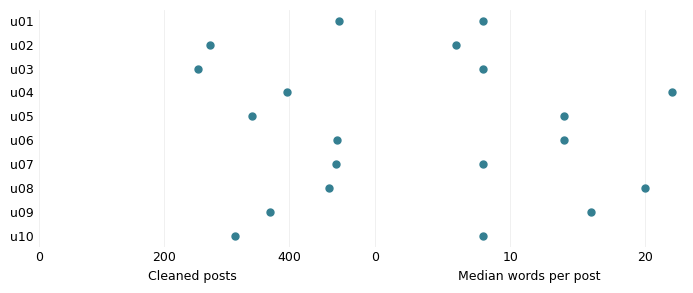

In [ ]:
# Cleaned posts before language filtering and balanced sampling.
posting_summary = pd.DataFrame({
    "Cleaned posts": data.groupby("uid").size(),
    "Median words per post": data.groupby("uid").n_words.median(),
}).sort_index()

with plt.rc_context({"font.size": 9}):
    fig, axes = plt.subplots(1, 2, figsize=(7, 3), sharey=True)
    for ax, column in zip(axes, posting_summary.columns):
        ax.scatter(posting_summary[column], posting_summary.index, s=25, color="#347f91")
        ax.set_xlabel(column)
        ax.set_xlim(left=0)
        ax.set_ylabel("")
        ax.set_axisbelow(True)
        ax.grid(axis="x", color="#eeeeee", linewidth=.6)
        ax.tick_params(axis="both", length=0)
        ax.locator_params(axis="x", nbins=3)
        for spine in ax.spines.values():
            spine.set_visible(False)
    axes[0].invert_yaxis()
    fig.tight_layout(w_pad=2)
    plt.show()


### Words and N-grams

A **unigram** is one token; a **bigram** is two adjacent tokens. Frequent phrases reveal patterns that single words can't show.


In [ ]:
# Start with observable words and phrases before weighting or embedding them.
explore_vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=2)
explore_counts = explore_vectorizer.fit_transform(sample.text)
explore_terms = explore_vectorizer.get_feature_names_out()
frequencies = pd.Series(np.asarray(explore_counts.sum(axis=0)).ravel(), index=explore_terms)
print("Frequent single words:")
display(frequencies.loc[~frequencies.index.str.contains(" ")].nlargest(10).rename("count").to_frame())
print("Frequent two-word phrases:")
display(frequencies.loc[frequencies.index.str.contains(" ")].nlargest(10).rename("count").to_frame())
vocabulary = sample.groupby("uid").agg(posts=("postid", "size"), median_words=("n_words", "median"))
vocabulary["unique_word_types"] = sample.groupby("uid").text.apply(
    lambda texts: len(set(re.findall(r"\b\w+\b", " ".join(texts).lower()))))
display(vocabulary)


Frequent single words:


,count
the,453
of,230
to,202
in,187
and,171
you,168
is,144
it,138
this,108
on,99


Frequent two-word phrases:


,count
thank you,58
in the,53
erin hanson,36
by erin,35
of the,35
face with,34
raccoonlove urbanwildlife,34
urbanwildlife natureexploration,34
jimothy seattle,31
seattle jimothyraccoon,31


,posts,median_words,unique_word_types
uid,,,
u01,80,13.5,467
u02,80,8.0,311
u05,80,16.5,768
u06,80,15.0,726
u07,80,14.0,502
u08,80,21.5,897
u09,80,32.5,689
u10,80,8.5,334


### Distinctive Terms

Which terms distinguish one user from the others? Compare their average TF–IDF weights.


In [ ]:
users = sorted(sample.uid.unique())
user_tfidf = np.vstack([np.asarray(X_tfidf[sample.uid.eq(u).to_numpy()].mean(axis=0)).ravel()
                        for u in users])
terms = tfidf.get_feature_names_out()
distinctiveness = user_tfidf - (user_tfidf.sum(axis=0) - user_tfidf) / (len(users)-1)
display(pd.DataFrame({"uid": users, "distinctive terms": [
    ", ".join(terms[np.argsort(row)[-8:][::-1]]) for row in distinctiveness]}))


,uid,distinctive terms
0,u01,"face, grinning, grinning face, eyes, eck, smiling, smiling eyes, face smiling"
1,u02,"abstractart, blueskyartshow, art, acrylics, acrylicart, perspective, blueskyartshow art, blueskyart"
2,u05,"time, im, lol, just, game, probably, ai, video"
3,u06,"trump, like, america, dolly, make, hegseth, expensive, sure"
4,u07,"heart, photography, rose, great, thank, green heart, jason, green"
5,u08,"israel, week, court, law, racist, adelaide, media, albo"
6,u09,"painting, oil, hanson, erin, erin hanson, thank, oil painting, dailyart"
7,u10,"jimothy, urbanwildlife, urbanwildlife natureexploration, raccoonlove urbanwildlife, raccoonlove, natureexploration, jimothyrac..."


## Exploration to Measurement

We have explored what is in the text, now let's measure -- Sentiment.

Sentiment analysis estimates whether a text expresses positive, negative, or neutral language. We use [VADER](https://github.com/cjhutto/vaderSentiment), an English sentiment lexicon with rules, for a short demonstration.


,post,score,sentiment
0,I had such a great day!,0.6588,Positive
1,I'm so tired of this awful situation.,-0.7346,Negative
2,The meeting starts at noon.,0.0000,Neutral


,post,sentiment,sentiment_score
570,My plan is coming together hahahaha \n\n#RaccoonLove #UrbanWildlife #NatureExploration,Neutral,0.0000
265,"Condolences to Norway on the passing of King Harald. He lived a remarkable life of service, resilience and quiet dignity. Hara...",Positive,0.8057
291,He took his website offline. afpacillo.com,Negative,-0.1280
597,Seen in downtown Cleveland today\n\n#jimothy #seattle #jimothyraccoon,Neutral,0.0000
174,"Its stream time! \n\nTonight I'll just be doodling some potential new dilles that either are one-time or, if ppl like them eno...",Positive,0.7249
247,"Trump’s ballroom playbook: do it first, get sued later, then argue it’s too late to undo. \n\nConcrete today. Ballots tomorrow.",Negative,-0.3400


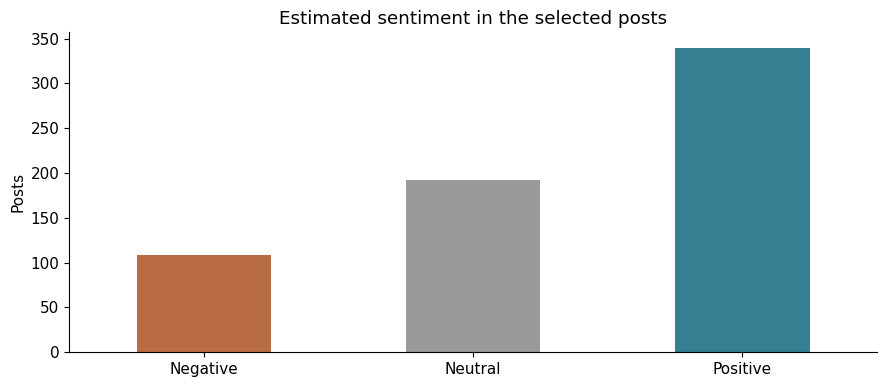

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
sentiment_model = SentimentIntensityAnalyzer()

def sentiment_label(score):
    # VADER's conventional compound-score thresholds.
    return "Positive" if score >= 0.05 else "Negative" if score <= -0.05 else "Neutral"

toy_sentiment = pd.DataFrame({"post": [
    "I had such a great day!", "I'm so tired of this awful situation.", "The meeting starts at noon."
]})
toy_sentiment["score"] = toy_sentiment.post.map(lambda text: sentiment_model.polarity_scores(text)["compound"])
toy_sentiment["sentiment"] = toy_sentiment.score.map(sentiment_label)
display(toy_sentiment)

sample["sentiment_score"] = sample.post.map(lambda text: sentiment_model.polarity_scores(text)["compound"])
sample["sentiment"] = sample.sentiment_score.map(sentiment_label)
display(sample[["post", "sentiment", "sentiment_score"]].sample(min(6, len(sample)), random_state=SEED))
sample.sentiment.value_counts().reindex(["Negative", "Neutral", "Positive"], fill_value=0).plot.bar(
    color=["#b96c43", "#999999", "#347f91"], rot=0)
plt.title("Estimated sentiment in the selected posts")
plt.ylabel("Posts"); plt.xlabel(""); plt.tight_layout(); plt.show()


Some

## Discovery from Unlabeled Text
### Semantic Similarity

Which posts express similar content? Sentence embeddings let us compare posts that use different wording but express related content. This can be relevant say for instance network related questions, or user level analysis.


#### Cosine Similarity and Nearest Neighbors

Cosine similarity compares vector directions. Use it to select a query post and find its **five most similar posts** in our chosen representation.

In [ ]:
S = cosine_similarity(R)
animal_posts = sample.loc[sample.text.str.contains(r"\b(?:cat|kitten|kitty|raccoon)\b", case=False, regex=True)]
QUERY_POST_ID = (animal_posts.iloc[0] if len(animal_posts) else sample.iloc[0]).postid
# Replace QUERY_POST_ID to explore another post.
query_index = sample.index[sample.postid.eq(QUERY_POST_ID)][0]
print("QUERY POST:")
show_posts(sample.iloc[[query_index]], 1)

# Exclude the query and identical cleaned text so repeated copies do not dominate.
allowed = sample.text.ne(sample.iloc[query_index].text).to_numpy()
ranked = np.argsort(-S[query_index])
selected = [j for j in ranked if allowed[j]][:5]
found = sample.iloc[selected][["uid", "postid", "time", "post", "text"]].copy()
found.insert(0, "cosine", S[query_index, selected])
print(f"FIVE NEAREST POSTS — {representation_label}:")
display(found[["cosine", "uid", "postid", "text"]])


QUERY POST:
u05  | 2026-09-01 23:53:12.640000+00:00
🐱 NEW VIDEO! 🐶   I feel for them. The catted Dog.  Link to the video in the thread! 🧵

FIVE NEAREST POSTS — MiniLM English embeddings:


,cosine,uid,postid,text
169,0.557795,u05,p1857,Do u see me more as a cat or a dog Cat Dog View results
178,0.545301,u05,p1912,"For a frame of reference of just how elephantine my next video is likely gonna be, I just surpassed the length of my CatDog vi..."
237,0.459642,u05,p2162,STREAM TIME! clown face grinning cat Tier List Tuesday is back once again! Starting template is ADULT CARTOONS! Hop in! Links ...
15,0.388222,u01,p0119,So funny and a gorgeous photo!! face with tears of joy
43,0.364681,u01,p0270,Aah! Such a sweetie. Beautiful shot. smiling face with heart-eyes


## Finding Structure - Topic Modeling

We can compare individual posts, but do broader themes emerge across the collection? One approach is to group posts by their representations, then examine what those groups are about.

**Representations → dimensionality reduction → clustering → topic words → interpretation**

### Dimensionality Reduction

Our sentence embeddings represent each post using 384 dimensions. This contains useful information, but it is difficult to visualize and can contain more complexity than we need for finding broader structure.

Dimensionality reduction compresses this information into fewer dimensions while trying to preserve important relationships between posts. Reducing to two dimensions lets us visualize the data; reducing to a larger number of dimensions can also make subsequent clustering more manageable.

| Method | Basic idea | Useful for |
|---|---|---|
| **PCA** | Finds main linear directions that capture the most variation in the data | A simple projection with explained variance |
| **UMAP** | Creates a nonlinear representation that tries to preserve local neighbourhoods, local points stay together | Visualization and preparation for density-based clustering |


#### PCA

PCA asks which directions capture the most overall variation, and we can project the posts onto anu number of components. The explained variance tells us how much of the variation these two components retain; visual overlap or separation alone does not establish meaningful topics.


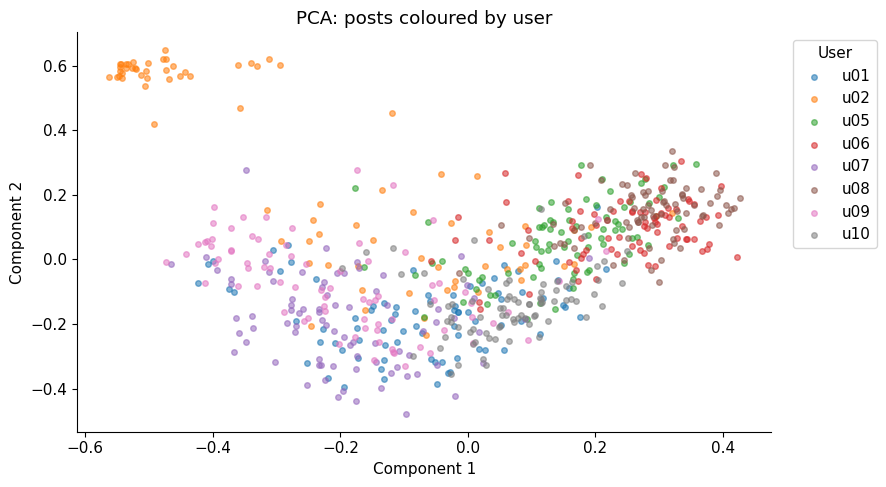

Variance represented by these two components: 11.9%


In [ ]:
# The small workshop sample fits in memory; PCA needs a dense matrix.
pca_input = R.toarray() if sparse.issparse(R) else R
projection = PCA(n_components=2, svd_solver="randomized", random_state=SEED)
coordinates = projection.fit_transform(pca_input)
fig, ax = plt.subplots(figsize=(9, 5))
palette = plt.get_cmap("tab10")
for i, user in enumerate(users):
    mask = sample.uid.eq(user).to_numpy()
    ax.scatter(coordinates[mask, 0], coordinates[mask, 1], s=16, alpha=.55,
               color=palette(i), label=user)
ax.set(title="PCA: posts coloured by user", xlabel="Component 1", ylabel="Component 2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="User")
plt.tight_layout(); plt.show()
print(f"Variance represented by these two components: {projection.explained_variance_ratio_.sum():.1%}")


#### UMAP

UMAP focuses on local neighbourhood structure. Which can be controled for using the `n_neighbors` and `min_dist` parameters.


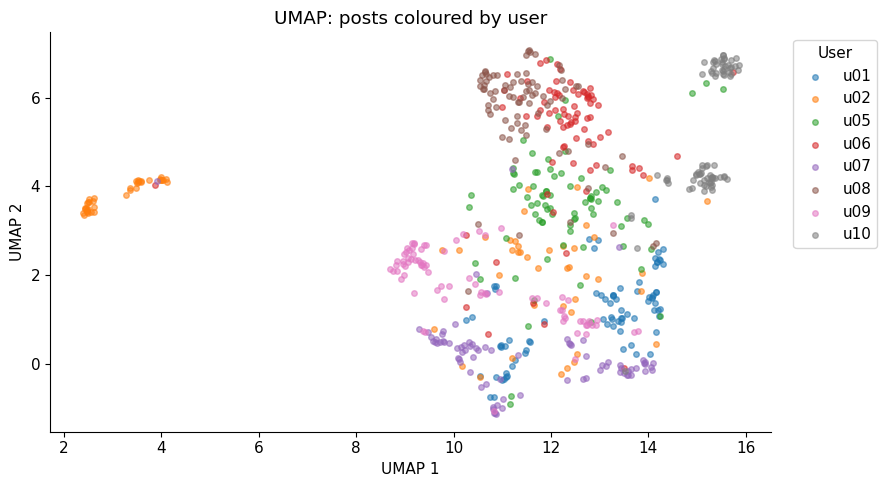

In [ ]:
from umap import UMAP
umap_input = R
xy = UMAP(n_neighbors=10, n_components=2, metric="cosine", random_state=SEED).fit_transform(umap_input)
fig, ax = plt.subplots(figsize=(9, 5))
for i, user in enumerate(users):
    mask = sample.uid.eq(user).to_numpy()
    ax.scatter(xy[mask, 0], xy[mask, 1], s=16, alpha=.55, color=palette(i), label=user)
ax.set(title="UMAP: posts coloured by user", xlabel="UMAP 1", ylabel="UMAP 2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="User")
plt.tight_layout(); plt.show()
reduced = UMAP(n_neighbors=15, n_components=5, metric="cosine", random_state=SEED).fit_transform(umap_input)


### Clustering

**Do posts form useful groups without predefined labels?**

Dimensionality reduction helps us see structure; **clustering** tries to group similar posts together. Different clustering methods make different assumptions about what a group looks like, and finding clusters does not necessarily mean that natural categories exist in the data.

We will compare two approaches:

- **K-means:** Pick K centers → assign each post to its nearest center → move the centers → repeat until assignments stabilize.
- **HDBSCAN:** Look for regions where many posts are packed together → treat those dense regions as clusters → leave isolated points as noise.

| | **K-means** | **HDBSCAN** |
|---|---|---|
| **Basic idea** | Groups posts around K centers | Finds dense groups of nearby posts |
| **You choose** | Number of clusters (`K`) | Minimum cluster size / density settings |
| **Every post assigned?** | Yes | No — `-1` indicates noise |
| **Useful when** | You want a fixed number of groups | You expect uneven groups and miscellaneous posts |
| **Main trade-off** | Will create K groups even when structure is weak | May leave many posts unassigned |


#### K-means

We cluster the original normalized representation. `K = 6` is a starting choice, not the true number of topics. Usually we use different methods to identify the optimal `K`.


In [ ]:
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(R)
sample["cluster"] = clusters


print(pd.Series(clusters).value_counts().sort_index().rename("posts"))


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


0     36
1    136
2     38
3     40
4    242
5    148
Name: posts, dtype: int64


#### HDBSCAN

Now find dense groups in the five-dimensional UMAP space. This changes both the representation and algorithm, so differences are not an isolated test of the clustering method. Noise is not automatically a topic.


In [ ]:
import hdbscan
density_model = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=5, prediction_data=True)
density_labels = density_model.fit_predict(reduced)
display(pd.Series(density_labels).value_counts().sort_index().rename("posts").to_frame())
print(f"Unassigned posts: {(density_labels == -1).mean():.1%}")
show_posts(sample.loc[density_labels == -1], 3)


/Users/oromia.sero/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/oromia.sero/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,posts
0,41
1,39
2,560


Unassigned posts: 0.0%


## From Clusters to Topics

**A cluster number is not a topic.** We interpret groups by moving through:

**Cluster → characteristic words → representative posts → provisional interpretation**


### Characteristic Words: c-TF–IDF

The earlier **TF–IDF** represented each **individual post**, highlighting words that distinguish it from other posts. **Class-based TF–IDF (c-TF–IDF)** combines the word counts of all posts in each **cluster**, treating the cluster as one document.

It weights words by their relative frequency within that cluster and discounts words that are common across the collection. This gives us characteristic words for describing an already-formed cluster; it does not create the clusters.

Here, each row describes a **K-means cluster**, with its size, number of users, and eight highest-weighted terms. Use these words and the posts below to propose a topic label.


In [ ]:
topic_vectorizer = CountVectorizer(min_df=2, max_df=.8, stop_words="english")
post_counts = topic_vectorizer.fit_transform(sample.text)
cluster_counts = np.vstack([
    np.asarray(post_counts[clusters == c].sum(axis=0)).ravel() for c in range(K)
])
average_length = cluster_counts.sum(axis=1).mean()
idf = np.log1p(average_length / np.maximum(cluster_counts.sum(axis=0), 1))
c_tfidf = normalize(cluster_counts, norm="l1") * idf
topic_terms = topic_vectorizer.get_feature_names_out()
topic_summary = pd.DataFrame({
    "cluster": range(K),
    "posts": [int((clusters == c).sum()) for c in range(K)],
    "users": [sample.loc[sample.cluster.eq(c), "uid"].nunique() for c in range(K)],
    "characteristic_terms": [", ".join(topic_terms[np.argsort(row)[-8:][::-1]]) for row in c_tfidf],
    "your_provisional_label": [""] * K,
})
display(topic_summary)


,cluster,posts,users,characteristic_terms,your_provisional_label
0,0,36,1,"urbanwildlife, raccoonlove, natureexploration, raccoon, did, caught, baby, right",
1,1,136,6,"painting, photography, oil, hanson, erin, art, dailyart, original",
2,2,38,1,"abstractart, blueskyartshow, art, acrylics, acrylicart, perspective, blueskyart, artistonbluesky",
3,3,40,1,"jimothy, jimothyraccoon, seattle, red, raccoon, heart, floor, laughing",
4,4,242,8,"like, trump, just, think, ve, make, doesn, don",
5,5,148,8,"thank, face, heart, grinning, eyes, smiling, great, hope",


### Representative Documents



In [ ]:
# Select posts closest to the fitted centroid, using the K-means distance.
distances = kmeans.transform(R)
CLUSTER_TO_READ = 0  # Participant control: try a different cluster.
members = np.flatnonzero(clusters == CLUSTER_TO_READ)
representatives = members[np.argsort(distances[members, CLUSTER_TO_READ])[:3]]
print(f"Near the center of cluster {CLUSTER_TO_READ}:")
show_posts(sample.iloc[representatives], 3)
print("Also read a far away post, to avoid interpreting only ideal examples:") # peripheral meaning far from the cluster center
show_posts(sample.iloc[[members[np.argmax(distances[members, CLUSTER_TO_READ])]]], 1)


Near the center of cluster 0:
u10  | 2026-06-22 01:06:59.100000+00:00
Baby raccoon!  #RaccoonLove #UrbanWildlife #NatureExploration

u10  | 2026-06-06 10:46:11.679000+00:00
New friend alert  #RaccoonLove #UrbanWildlife #NatureExploration

u10  | 2026-04-19 20:01:06.230000+00:00
This is Lefty  #RaccoonLove #UrbanWildlife #NatureExploration

Also read a far away post, to avoid interpreting only ideal examples:
u10  | 2026-09-06 09:12:45.397000+00:00
Good morning, everyone! 🦝🌿 Just popping in to wish you a wonderful morning. What did you all have
for breakfast today? Is there any delicious food left for me? Let me know in the comments! ❤️🐾
#jimothy #seattle #jimothyraccoon



## BERTopic: Putting it all together

We have built the main pieces of a topic-modelling pipeline:

**Embeddings → dimensionality reduction → clustering → topic words → interpretation**

BERTopic combines these steps in one framework. Here we reuse our UMAP projection and HDBSCAN settings, then let BERTopic generate topic descriptions. Topic `-1` contains unassigned posts. Read a few examples before naming a topic.


In [ ]:
from bertopic import BERTopic
from bertopic.dimensionality import BaseDimensionalityReduction

topic_model = BERTopic(
    umap_model=BaseDimensionalityReduction(),  # Use our already-computed projection.
    hdbscan_model=hdbscan.HDBSCAN(min_cluster_size=20, min_samples=5, prediction_data=True),
    vectorizer_model=CountVectorizer(stop_words="english"),
    calculate_probabilities=False,
)
bertopic_labels, _ = topic_model.fit_transform(sample.text.tolist(), embeddings=reduced)
display(topic_model.get_topic_info())
non_noise_topics = sorted(set(bertopic_labels) - {-1})
if non_noise_topics:
    topic_to_read = non_noise_topics[0]
    for text in (topic_model.get_representative_docs(topic_to_read) or [])[:3]:
        print(textwrap.fill(text, width=100), "\n")
else:
    print("No non-noise topics found with these settings. Inspect the density settings and texts.")


,Topic,Count,Name,Representation,Representative_Docs
0,0,560,0_jimothy_thank_heart_face,"[jimothy, thank, heart, face, photography, painting, oil, just, jimothyraccoon, hanson]","[Thank you Jason. Have a great rest of the day! green heart blue heart green heart, The recognizably rainbow hues of the Grand..."
1,1,41,1_abstractart_blueskyartshow_art_acrylics,"[abstractart, blueskyartshow, art, acrylics, acrylicart, perspective, blueskyart, artistonbluesky, abstractexpressionism, abst...","[perspective acrylics abstractart acrylicart art blueskyartshow, perspective acrylics abstractart blueskyartshow art acrylicar..."
2,2,39,2_urbanwildlife_raccoonlove_natureexploration_raccoon,"[urbanwildlife, raccoonlove, natureexploration, raccoon, baby, caught, right, did, sad, absolutely]","[is this raccoon in labor? RaccoonLove UrbanWildlife NatureExploration, Baby raccoon! RaccoonLove UrbanWildlife NatureExplorat..."


Thank you Jason. Have a great rest of the day! green heart blue heart green heart 

The recognizably rainbow hues of the Grand Canyon pop from the canvas in this oil painting by
American impressionist Erin Hanson. Amethyst Light Original Oil Painting by Erin Hanson, 2022 30 x
40 in nps grandcanyon art dailyart contemporaryartist 

Time to meet the day red heart jimothy seattle jimothyraccoon 



## Evaluation

1. **Do the clusters separate?** Silhouette  - higher values indicate clearer separation under that distance measure.
2. **Are the results stable?** Try a reasonable change to `K` or the UMAP/HDBSCAN settings. Do the broad themes persist?
3. **Do the topics make sense?** Read representative posts and counterexamples. Evaluation metrics might not map to meaningful topics.

**Topic coherence:** Measures such as **C_v** and **NPMI** assess how strongly a topic's top words occur together in a reference collection. This complements silhouette: coherence evaluates topic words, while silhouette evaluates separation between groups of posts. [Coherence measures](https://radimrehurek.com/gensim/models/coherencemodel.html).


## References and Further Reading

This notebook draws on the structure of June Yang's workshop, with adapted examples and methods.

- **Yang, June. (2026). *Introduction to Text as Data*.** CSDE and eScience Institute. [*Text as Data and LLM Applications*](https://csde.washington.edu/workshop/introduction-to-text-as-data/), University of Washington CSDE.

- **Grimmer, Justin, Margaret E. Roberts, and Brandon M. Stewart. (2022). *Text as Data: A New Framework for Machine Learning and the Social Sciences*.** Princeton University Press. A foundation for selection, representation, discovery, measurement, and validation. [Book information](https://bstewart.scholar.princeton.edu/publications/text-data-new-framework-machine-learning-and-social-sciences).

### More Resources

- **Hill, Benjamin Mako. (2026). *Text as Data (Spring 2026)*.** University of Washington, COM 597 B / CSSS 594 A. A graduate course syllabus with readings on text representation, topic modelling, measurement, and validation. [Course materials](https://wiki.communitydata.science/Text_as_Data_%28Spring_2026%29).

- **Hugging Face. *LLM Course*, Chapter 1: Transformer Models.** An introduction to how transformers work. [Course chapter](https://huggingface.co/learn/llm-course/chapter1/5).

- **VADER sentiment analysis.** Documentation for the sentiment method used here. [Vader](https://github.com/cjhutto/vaderSentiment).

- **BERTopic Documentation** [BERTopic](https://maartengr.github.io/BERTopic/algorithm/algorithm.html).
